## Notes on setup

- the conda env is called food_data
- in terminal run `conda activate food_data`
- in vs code select food_data as the kernel

conda adds the python packages we need. packages are programs we can use like pandas. they are hosed on the internet and we install them with conda. 

we made conda env food_data (same as dir) so that we can install packages (libraries) without conflicting with anything else

# How to use

1. copy a new receipt to the recipts/images dir
2. run the cell bellow
3. reload the dataframe in the analysis cell below

Notes
- uses sqlite to track which images have been processed no need to remove images from the directory. will only process new photos

In [16]:
import pandas as pd
import sqlite3
import os
from datetime import datetime
import glob
import requests
import base64
import json
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from typing import List, Optional
from pydantic import BaseModel, Field
from langchain_core.runnables import RunnablePassthrough
from langchain_core.runnables import RunnableLambda

OPENROUTER_API_KEY = os.environ.get("OPEN_ROUTER_KEY")
if OPENROUTER_API_KEY is None:
    raise Exception("Please set OPENROUTER_API_KEY")

OPENROUTER_API_URL = "https://openrouter.ai/api/v1/chat/completions"
MODEL = "google/gemini-2.0-flash-exp:free"

# Define Pydantic Schemas
class ReceiptItem(BaseModel):
    Item: str = Field(description="Name of the item")
    Quantity: float = Field(description="Quantity of the item")
    Price: float = Field(description="Price of the item")
    Weight: Optional[float] = Field(description="Weight of the item", default=None)
    Price_per_Weight: Optional[float] = Field(
        description="Price per weight of item", default=None
    )

class Receipt(BaseModel):
    items: List[ReceiptItem] = Field(description="List of items")

# Langchain components
output_parser = PydanticOutputParser(pydantic_object=Receipt)

prompt_template = """
You are a CSV generation machine. Follow these rules ABSOLUTELY:
1. Output ONLY raw CSV data with columns: Item,Quantity,Price,Weight,Price_per_Weight
2. No headers, explanations, or markdown formatting
3. Mandatory fields: Item, Quantity, Price (skip row if any missing)
4. Only include Weight/Price_per_Weight if explicitly shown
5. Format numbers without currency symbols
6. If quantity not specified, use 1
7. Never invent values - omit uncertain items

Example Output:
CILANTRO PACKAGE,1,1.50,,
BE SF BROCCOLI CUT,1,2.99,,
LIME,2,0.58,,
ASPARAGUS GREEN SM,0.36,0.72,0.36,1.99
"""

prompt = ChatPromptTemplate.from_messages([
    ("user", prompt_template),
    ("user", "<image>")
])

def process_image_with_llm(image_path, prompt_text):
    try:
        with open(image_path, "rb") as image_file:
            encoded_image = base64.b64encode(image_file.read()).decode("utf-8")
        headers = {
            "Authorization": f"Bearer {OPENROUTER_API_KEY}",
            "Content-Type": "application/json",
        }
        data = {
            "model": MODEL,
            "messages": [
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt_text},
                        {
                            "type": "image_url",
                            "image_url": {"url": f"data:image/jpeg;base64,{encoded_image}"},
                        },
                    ],
                },
            ]
        }
        response = requests.post(
            OPENROUTER_API_URL, headers=headers, data=json.dumps(data)
        )
        response.raise_for_status()
        json_response = response.json()
        print(json_response["choices"][0]["message"]["content"])
        return json_response["choices"][0]["message"]["content"]
    except Exception as e:
        print(f"Error processing image '{image_path}' with OpenRouter: {e}")
        return None

def parse_csv_response(response: str) -> Receipt:
    items = []
    
    for line in response.split('\n'):
        line = line.strip()
        if not line:
            continue
            
        parts = [part.strip() for part in line.split(',')]
        try:
            # Validate required fields
            if len(parts) < 3:
                raise ValueError("Missing required fields")
                
            item_data = {
                "Item": parts[0],
                "Quantity": float(parts[1]),
                "Price": float(parts[2])
            }
            
            # Handle optional fields
            if len(parts) > 3 and parts[3]:
                item_data["Weight"] = float(parts[3])
            if len(parts) > 4 and parts[4]:
                item_data["Price_per_Weight"] = float(parts[4])
                
            items.append(ReceiptItem(**item_data))
            
        except (ValueError, IndexError) as e:
            print(f"Skipping invalid line: {line} - Error: {e}")
            
    return Receipt(items=items)

def ingest_images(images_dir, db_path):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS receipt_items (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            image_path TEXT,
            item TEXT,
            quantity REAL,
            price REAL,
            weight REAL,
            price_per_weight REAL,
            timestamp DATETIME DEFAULT CURRENT_TIMESTAMP
        )
    """)
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS processed_images (
            image_path TEXT PRIMARY KEY,
            timestamp DATETIME DEFAULT CURRENT_TIMESTAMP
        )
    """)

    processed_images = set(
        row[0] for row in cursor.execute("SELECT image_path FROM processed_images").fetchall()
    )

    for image_path in glob.glob(os.path.join(images_dir, "*.*")):
        if image_path in processed_images:
            continue
            
        try:
            # Create processing chain
            chain = (
                RunnablePassthrough.assign(
                    format_instructions=lambda _: format_instructions
                )
                | prompt
                | RunnableLambda(lambda x: process_image_with_llm(image_path, x.messages[0].content))
                | RunnableLambda(parse_csv_response)
            )
            
            receipt_data = chain.invoke({})
            
            # Insert valid items
            for item in receipt_data.items:
                cursor.execute("""
                    INSERT INTO receipt_items 
                    (image_path, item, quantity, price, weight, price_per_weight)
                    VALUES (?, ?, ?, ?, ?, ?)
                """, (
                    image_path,
                    item.Item,
                    item.Quantity,
                    item.Price,
                    item.Weight,
                    item.Price_per_Weight,
                ))
                
            cursor.execute("INSERT INTO processed_images (image_path) VALUES (?)", (image_path,))
            conn.commit()
            print(f"Processed {len(receipt_data.items)} items from {os.path.basename(image_path)}")
            
        except Exception as e:
            print(f"Failed to process {os.path.basename(image_path)}: {e}")
            conn.rollback()

    conn.close()

if __name__ == "__main__":
    base_dir = os.getcwd()
    receipts_dir = os.path.join(base_dir, "receipts")
    images_dir = os.path.join(receipts_dir, "images")
    db_path = os.path.join(receipts_dir, "receipts.db")
    os.makedirs(images_dir, exist_ok=True)
    
    ingest_images(images_dir, db_path)


BANANA GREEN ROSY,1,1.45,,
BLUEBERRY,1,2.50,,
CHOBANI GREEK YOG NON F,1,7.99,,
KIWI 6PK,1,5.99,,
ORGANIC GIORGIO BABY BE,1,4.49,,
PEPPER RED,1,1.92,0.32,5.99
CABBAGE RED,1,2.86,2.40,1.19
THE FRUITIST RASPBERRIE,1,4.49,,
SUNLIT SPICY BULGOGI,1,6.99,,

Processed 9 items from bravo1.jpg
CILANTRO PACKAGE,1,1.50,,
BGPA TOTE BG U/E R,1,1.49,,
SALMON-ORGANIC FIL,1,14.39,,
BE VEG POLY CAUL,1,3.50,,
BE SF BROCCOLI CUT,1,2.99,,
LIME,2,0.58,,
DEP RE-FRIED BEANS,1,2.00,,
TO TRAD JASM GRN,1,2.59,,
GARLIC- LOOSE,1,0.50,0.10,4.99
LEMON,1,0.34,,
BGPA PAPAYA PULP,1,2.00,,
BE STM CHEESY BROC,1,3.50,,
ORG-SHITTAKE MUSHR,1,4.99,,
SCALLION,1,0.67,,
ASPARAGUS GREEN SM,1,5.14,1.03,4.99
RADISH- LOOSE,1,0.72,0.36,1.99
DAISY SOUR CREAM,1,2.99,,
NISS NOODLE CUP RA,1,2.79,,
NISS NOODLE CUP RA,1,2.89,,
MARUKOME R/S MISO,1,6.69,,
CBT SHRD ARTISAN P,1,3.00,,
GINGER,1,0.16,0.08,1.99
BOK CHOY,1,1.45,0.73,1.99
"OMATO- STEM,1,3.11,1.25,2.49
ONION- RED LOOSE,1,1.67,0.34,1.99
HAKUBAKU NOODLES O,1,4.29,,
CTO TRAD JASM GRN,

## Analize the data

In [19]:
import pandas as pd
import sqlite3
import os

def load_data_from_sqlite(db_path):
     """
     Loads processed data from the SQLite database into a pandas DataFrame.
     
     Args:
         db_path (str): Path to the SQLite database file.
     Returns:
         pandas.DataFrame: The pandas DataFrame with the processed data.
     """
     try:
         conn = sqlite3.connect(db_path)
         query = """
             SELECT 
                 item, 
                 quantity, 
                 price, 
                 weight, 
                 price_per_weight 
             FROM receipt_items
         """
         df = pd.read_sql_query(query, conn)
         conn.close()
         print("Loaded data from sqlite")
         return df
     except Exception as e:
             print(f"Error loading from SQLite: {e}")
             return None

if __name__ == '__main__':
     # Set the directory paths
     base_dir = os.getcwd()
     receipts_dir = os.path.join(base_dir,'receipts')
     db_path = os.path.join(receipts_dir,'receipts.db')

     # LOAD DATA CELL
     df = load_data_from_sqlite(db_path)
       # Print out dataframe
     if df is not None:
         print(df)

Loaded data from sqlite
                       item  quantity  price  weight  price_per_weight
0         BANANA GREEN ROSY       1.0   1.45     NaN               NaN
1                 BLUEBERRY       1.0   2.50     NaN               NaN
2   CHOBANI GREEK YOG NON F       1.0   7.99     NaN               NaN
3                  KIWI 6PK       1.0   5.99     NaN               NaN
4   ORGANIC GIORGIO BABY BE       1.0   4.49     NaN               NaN
5                PEPPER RED       1.0   1.92    0.32              5.99
6               CABBAGE RED       1.0   2.86    2.40              1.19
7   THE FRUITIST RASPBERRIE       1.0   4.49     NaN               NaN
8      SUNLIT SPICY BULGOGI       1.0   6.99     NaN               NaN
9          CILANTRO PACKAGE       1.0   1.50     NaN               NaN
10       BGPA TOTE BG U/E R       1.0   1.49     NaN               NaN
11       SALMON-ORGANIC FIL       1.0  14.39     NaN               NaN
12         BE VEG POLY CAUL       1.0   3.50     NaN 

## Pandas SQL example

In [24]:
from pandasql import sqldf
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [21]:
def run_sql_query(df, query):
    """
    Runs a SQL query against a pandas DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to query.
        query (str): The SQL query to run.

    Returns:
        pandas.DataFrame: The result of the query as a DataFrame.
    """
    try:
        #pandasql requires the namespace to be global
        global_vars = {'df': df}
        result = sqldf(query,global_vars)
        return result
    except Exception as e:
        print(f"Error running SQL query: {e}")
        return None

query1 = """
    SELECT item, SUM(price) AS total_spent
    FROM df
    GROUP BY item
    ORDER BY total_spent DESC
    LIMIT 5;
"""

query2 = """
    SELECT item, AVG(price) AS average_price
    FROM df
    GROUP BY item
    HAVING COUNT(*) > 1
    ORDER BY average_price DESC;
"""

# Run and print query results
result1 = run_sql_query(df, query1)
if result1 is not None:
    print("\nTop 5 Items by Total Spent:")
    print(result1)

result2 = run_sql_query(df, query2)
if result2 is not None:
    print("\nAverage Price of Items (with count > 1):")
    print(result2)


Top 5 Items by Total Spent:
                      item  total_spent
0       SALMON-ORGANIC FIL        14.39
1       SH CITON TEA W/HNY        10.49
2  CHOBANI GREEK YOG NON F         7.99
3     SUNLIT SPICY BULGOGI         6.99
4        MARUKOME R/S MISO         6.69

Average Price of Items (with count > 1):
                 item  average_price
0  NISS NOODLE CUP RA           2.84
1    ONION- RED LOOSE           2.11


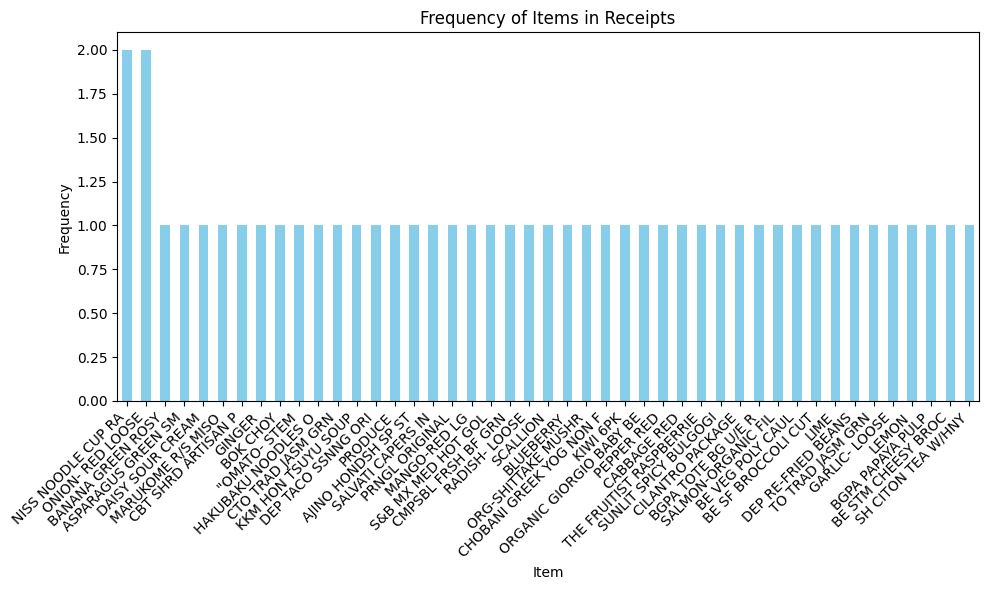

In [25]:
item_counts = df['item'].value_counts()
plt.figure(figsize=(10, 6))
item_counts.plot(kind='bar', color='skyblue')
plt.title('Frequency of Items in Receipts')
plt.xlabel('Item')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()